# Import necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import utm
from sklearn.preprocessing import StandardScaler
import math

# Remove warning 

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [3]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [4]:
df.shape

(84593, 186)

# List the Features

In [5]:
column_names = df.columns.tolist()
print("Column Names:")
for column_name in column_names:
    print(column_name)

Column Names:
CUSTOM.date [local]
CUSTOM.updateTime [local]
OSD.flyTime
OSD.flyTime [s]
OSD.latitude
OSD.longitude
OSD.height [ft]
OSD.heightMax [ft]
OSD.vpsHeight [ft]
OSD.altitude [ft]
OSD.mileage [ft]
OSD.hSpeed [MPH]
OSD.hSpeedMax [MPH]
OSD.xSpeed [MPH]
OSD.xSpeedMax [MPH]
OSD.ySpeed [MPH]
OSD.ySpeedMax [MPH]
OSD.zSpeed [MPH]
OSD.zSpeedMax [MPH]
OSD.pitch
OSD.roll
OSD.yaw
OSD.yaw [360]
OSD.flycState
OSD.flycCommand
OSD.flightAction
OSD.gpsNum
OSD.gpsLevel
OSD.isGPSUsed
OSD.nonGPSCause
OSD.droneType
OSD.isSwaveWork
OSD.waveError
OSD.goHomeStatus
OSD.batteryType
OSD.ctrlDevice
OSD.isOnGround
OSD.isMotorOn
OSD.isMotorBlocked
OSD.motorStartFailedCause
OSD.motorFailReason
OSD.isImuPreheated
OSD.imuInitFailReason
OSD.isAcceletorOverRange
OSD.isBarometerDeadInAir
OSD.isCompassError
OSD.isGoHomeHeightModified
OSD.canIOCWork
OSD.isNotEnoughForce
OSD.isOutOfLimit
OSD.isPropellerCatapult
OSD.isVibrating
OSD.isVisionUsed
OSD.voltageWarning
GIMBAL.mode
GIMBAL.pitch
GIMBAL.roll
GIMBAL.yaw
GIMBAL

# Feature Selection

In [6]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [7]:
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0m 0.0s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,113.9
1,0m 0.1s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
2,0m 0.2s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
3,0m 0.3s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
4,0m 0.4s,1024,1024,1024,1024,80.353166,7.498429,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
84588,10m 14.7s,1024,1024,364,1024,79.915921,6.972900,1.6,6.0,-0.4,-81.7
84589,10m 14.8s,1024,1024,364,1024,79.915921,6.972900,1.6,6.4,-0.4,-82.6
84590,10m 14.9s,1024,1024,364,1024,79.915921,6.972900,1.6,6.8,-0.4,-83.1
84591,10m 15.0s,1024,1024,364,1024,79.915921,6.972900,1.6,7.3,-1.0,-83.6


# Convert time string to seconds function

In [8]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Data Analysis

# Range of each features

Range of values for each feature:
                        min          max
OSD.flyTime        0.000000  1176.300000
RC.aileron       364.000000  1684.000000
RC.elevator      364.000000  1684.000000
RC.throttle      364.000000  1684.000000
RC.rudder        364.000000  1684.000000
OSD.longitude     79.913877    80.353385
OSD.latitude       6.972471     7.498461
OSD.height [ft]   -6.800000   115.800000
OSD.pitch        -29.400000    29.000000
OSD.roll         -25.600000    28.400000
OSD.yaw         -179.900000   179.900000


<Figure size 1200x600 with 0 Axes>

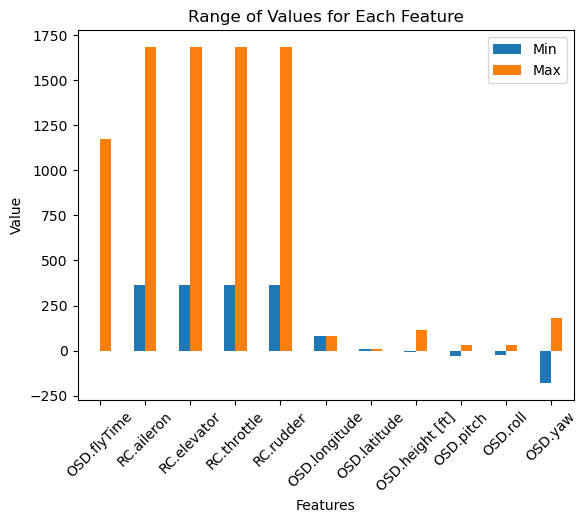

In [9]:
feature_ranges = df.describe().loc[['min', 'max']]

# Transpose the DataFrame for easier plotting
feature_ranges = feature_ranges.transpose()

print("Range of values for each feature:")
print(feature_ranges)
# Plot the range of values for each feature
plt.figure(figsize=(12, 6))
feature_ranges.plot(kind='bar', rot=45)
plt.title('Range of Values for Each Feature')
plt.xlabel('Features')
plt.ylabel('Value')
plt.legend(['Min', 'Max'])
plt.show()

In [10]:
# Calculate summary statistics for the dataset
summary_stats = df.describe()

# Display the summary statistics
summary_stats

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
count,84593.000000,84593.000000,84593.000000,84593.000000,84593.000000,84593.000000,84593.000000,84593.000000,84593.000000,84593.000000,84593.000000
mean,415.243921,1022.895831,1140.452342,992.401416,1025.124549,79.928291,6.989764,11.457148,0.730887,-0.714149,5.419109
std,289.645776,43.385361,232.801015,241.626948,223.335369,0.075339,0.090164,19.249065,4.421873,2.273443,90.799882
min,0.000000,364.000000,364.000000,364.000000,364.000000,79.913877,6.972471,-6.800000,-29.400000,-25.600000,-179.900000
25%,168.600000,1024.000000,1024.000000,1024.000000,1024.000000,79.914256,6.972924,1.900000,-1.100000,-1.600000,-55.700000
50%,371.400000,1024.000000,1024.000000,1024.000000,1024.000000,79.914681,6.974181,3.900000,1.100000,-0.500000,0.100000
75%,620.900000,1024.000000,1263.000000,1024.000000,1024.000000,79.915895,6.974349,10.400000,2.500000,0.300000,73.100000
max,1176.300000,1684.000000,1684.000000,1684.000000,1684.000000,80.353385,7.498461,115.800000,29.000000,28.400000,179.900000


# Convert latitude and longitude into coordinates

In [11]:
# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon
    
    # Convert the differences to meters using an appropriate conversion factor
    # Note: The conversion factor depends on your specific projection method
    # For simplicity, assuming 1 degree of latitude = 111.32 km and 1 degree of longitude = 111.32 km * cos(latitude)
    lat_to_m = 111320.0  # meters per degree of   at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Assume 'df' is your DataFrame with columns 'OSD.latitude' and 'OSD.longitude'
# Define your local projection origin point
origin_lat = df['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df[['local_x', 'local_y']] = df.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Replace 'OSD.latitude' and 'OSD.longitude' values with 'local_x' and 'local_y' respectively
df['OSD.latitude'] = df['local_x']
df['OSD.longitude'] = df['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df.drop(columns=['local_x', 'local_y'], inplace=True)

# Print the DataFrame
df.head()


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,0.000000,0.000000,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,-0.003562,0.003311,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,-0.013915,0.014348,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,-0.018034,0.017659,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,-0.027273,0.008829,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [12]:
null_counts = df.isnull().sum(axis=0)
print(null_counts)

OSD.flyTime        0
RC.aileron         0
RC.elevator        0
RC.throttle        0
RC.rudder          0
OSD.longitude      0
OSD.latitude       0
OSD.height [ft]    0
OSD.pitch          0
OSD.roll           0
OSD.yaw            0
dtype: int64


## Identify Outliers

<Figure size 1500x1000 with 0 Axes>

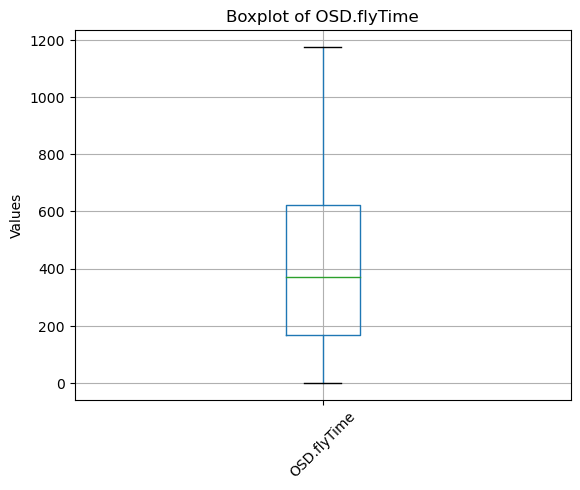

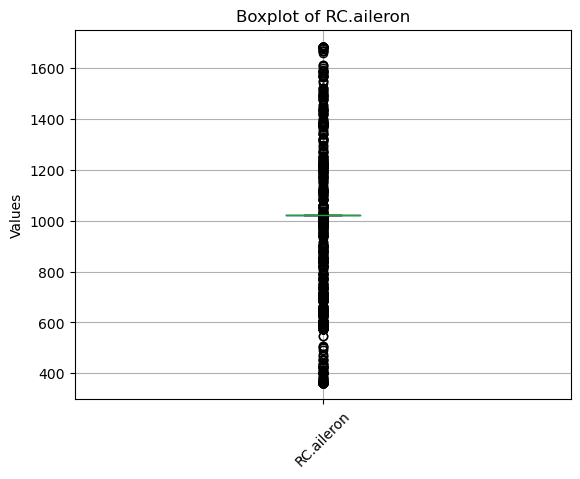

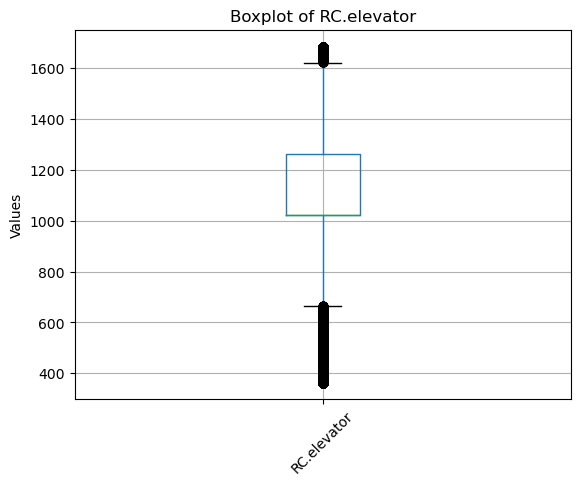

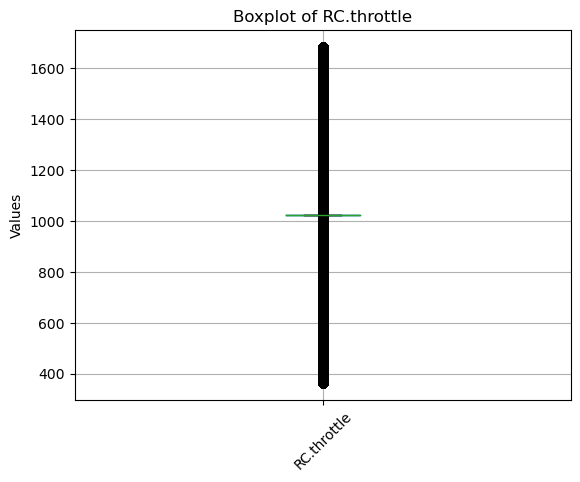

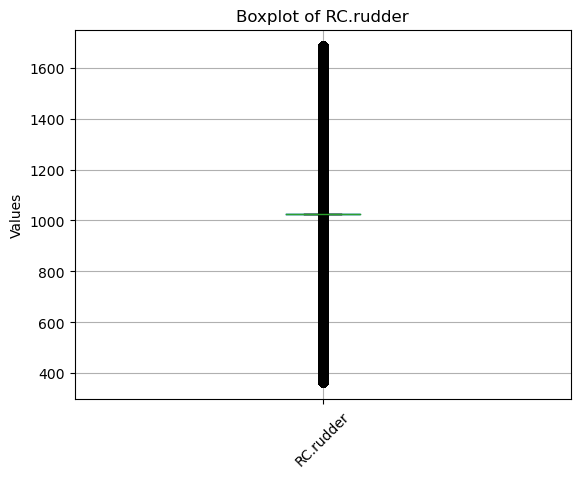

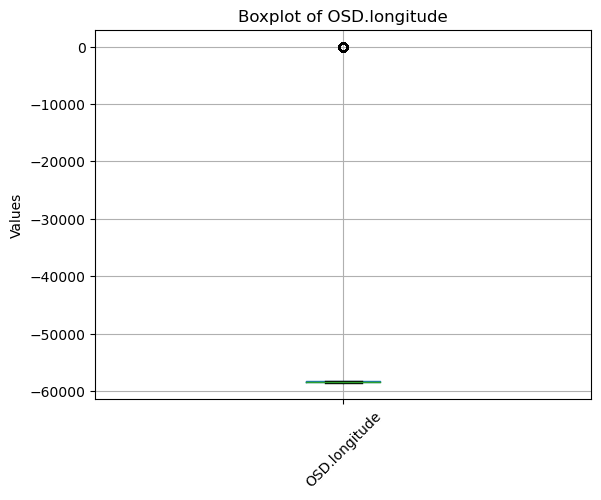

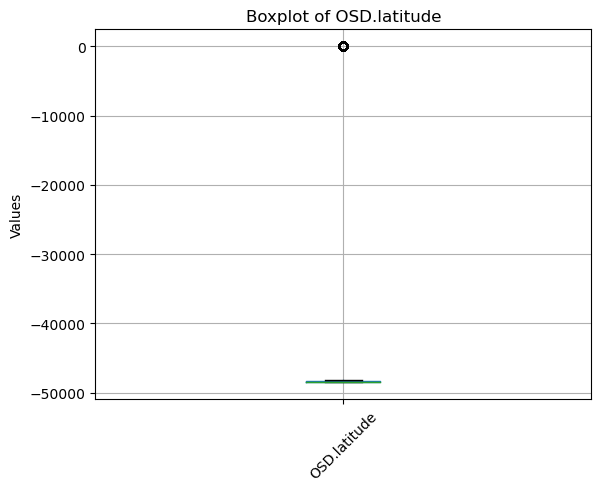

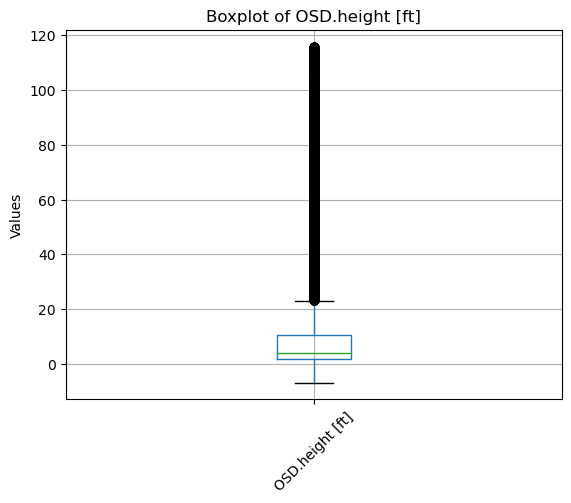

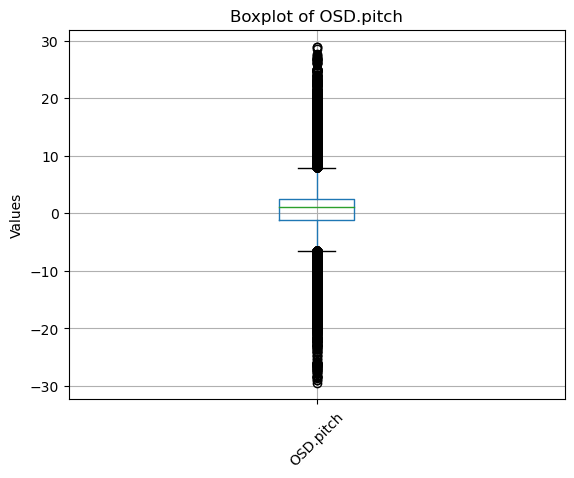

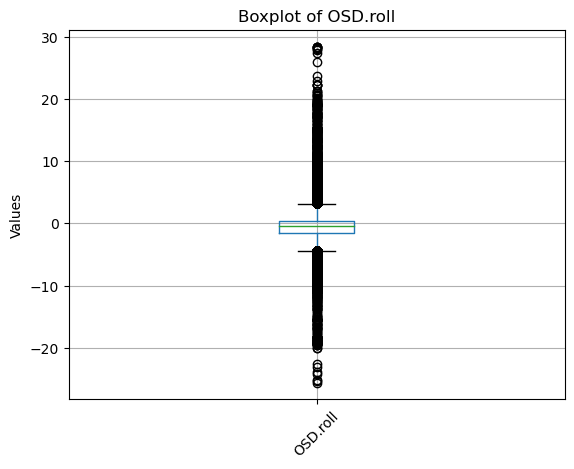

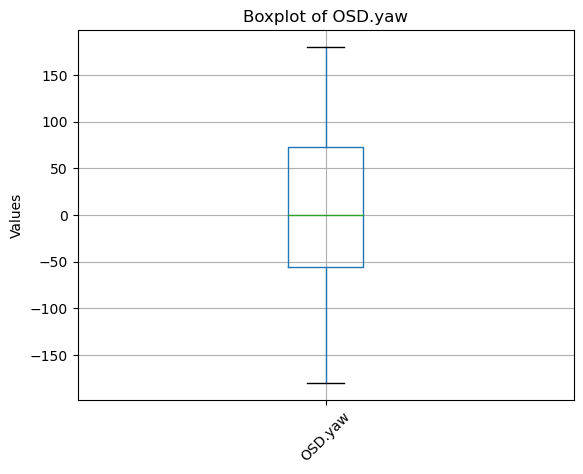

In [13]:
plt.figure(figsize=(15, 10))
for column in df.columns:
    plt.figure()
    df.boxplot(column=[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel('Values')
    plt.xticks(rotation=45)
    plt.show()

### Number of outliers for each feature

In [14]:
# Initialize an empty dictionary to store the number of outliers for each feature
outliers_count = {}

# Initialize total outliers count
total_outliers_count = 0

# Calculate the first quartile (Q1) and third quartile (Q3) for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR) for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Loop through each feature and count the number of outliers
for feature in df.columns:
    outliers_count[feature] = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    total_outliers_count += ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()

# Display the number of outliers for each feature
print("Number of outliers for each feature:")
for feature, count in outliers_count.items():
    print(f"{feature}: {count}")
      
# Display the total number of outliers
print("Total number of outliers:", total_outliers_count)


Number of outliers for each feature:
OSD.flyTime: 0
RC.aileron: 953
RC.elevator: 6968
RC.throttle: 20116
RC.rudder: 18932
OSD.longitude: 2577
OSD.latitude: 2577
OSD.height [ft]: 12139
OSD.pitch: 6972
OSD.roll: 5551
OSD.yaw: 0
Total number of outliers: 76785


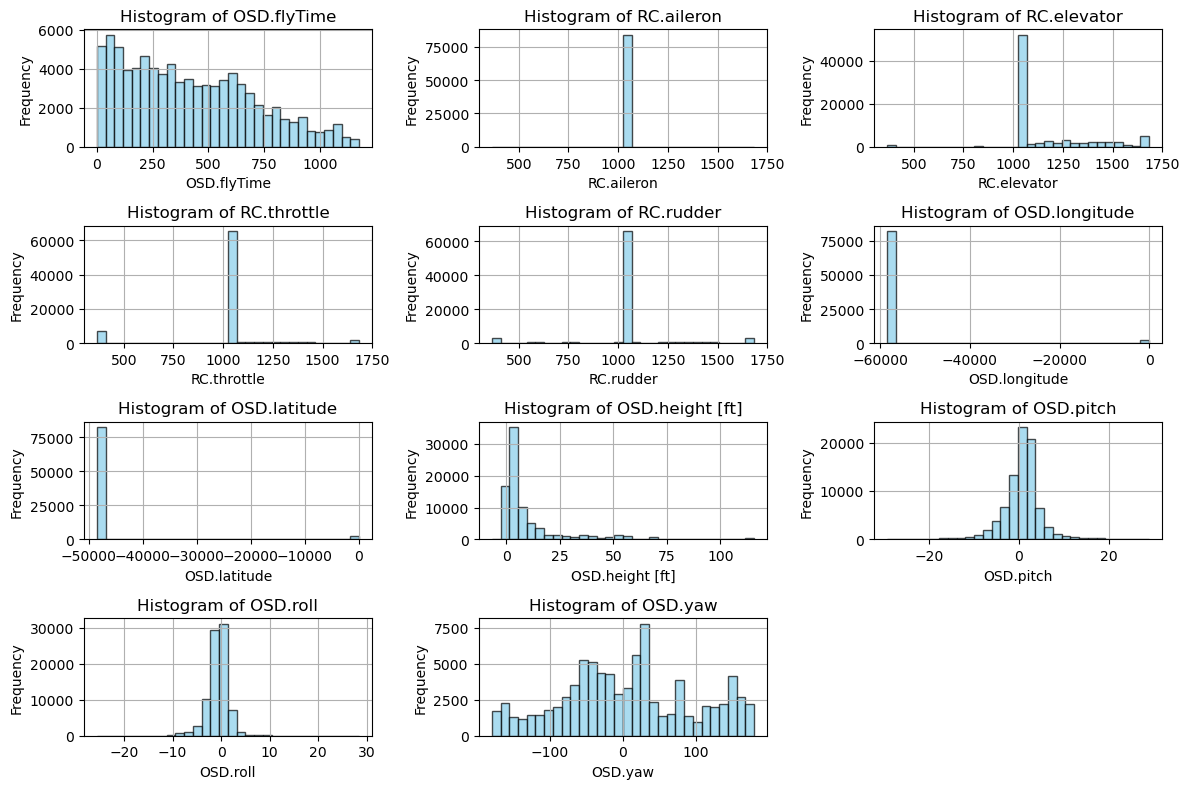

In [15]:
import matplotlib.pyplot as plt

# Plot histograms for all features in df
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df.columns):
    plt.subplot(4, 3, i+1)  # Adjust the subplot layout as needed
    plt.hist(df[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()  # Adjust the layout to prevent overlapping subplots
plt.show()


### Total outliers by rowise

#### In the first code snippet, outliers are counted for each feature individually, and then the total number of outliers is obtained by summing up these counts. This approach counts the outliers separately for each feature, resulting in a higher total count because it's possible for a data point to be an outlier in multiple features.In the second code snippet, outliers are detected based on whether any feature in a row exceeds the lower or upper bounds. This approach counts the total number of rows with at least one outlier, which may result in a lower total count because each row is counted only once, regardless of how many features in that row contain outliers.

In [16]:
# Calculate the first quartile (Q1) and third quartile (Q3)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = ((df < lower_bound) | (df > upper_bound)).any(axis=1)

# Print number of outliers
print("Number of outliers:", outliers.sum())


Number of outliers: 51847


In [17]:
# Define a function to calculate outliers based on a criterion
def calculate_outliers(data, criterion):
    """
    Calculate outliers based on a criterion.

    Parameters:
    - data: 1D numpy array containing the feature data
    - criterion: Criterion for defining outliers (e.g., threshold value)

    Returns:
    - num_outliers: Number of outliers in the feature data
    """
    # Calculate median or mean of the data
    data_median = np.median(data)
    # Identify outliers based on the criterion
    outliers = data[data > criterion * data_median]
    # Count the number of outliers
    num_outliers = len(outliers)
    return num_outliers

# Define a threshold for identifying outliers (e.g., 1.5 times the median)
threshold = 1.5

# Calculate the number of outliers for each feature
num_outliers_per_feature = {}
for feature in features:
    num_outliers_per_feature[feature] = calculate_outliers(df[feature].values, threshold)

# Print the number of outliers for each feature
for feature, num_outliers in num_outliers_per_feature.items():
    print(f"Number of outliers in {feature}: {num_outliers}")


Number of outliers in OSD.flyTime: 27056
Number of outliers in RC.aileron: 100
Number of outliers in RC.elevator: 7281
Number of outliers in RC.throttle: 2516
Number of outliers in RC.rudder: 3825
Number of outliers in OSD.longitude: 84593
Number of outliers in OSD.latitude: 84593
Number of outliers in OSD.height [ft]: 31916
Number of outliers in OSD.pitch: 34901
Number of outliers in OSD.roll: 47771
Number of outliers in OSD.yaw: 42189


In [18]:
# Calculate the total number of outliers in the dataset
total_outliers = sum(num_outliers_per_feature.values())

# Print the total number of outliers in the dataset
print(f"Total number of outliers in the dataset: {total_outliers}")


Total number of outliers in the dataset: 366741


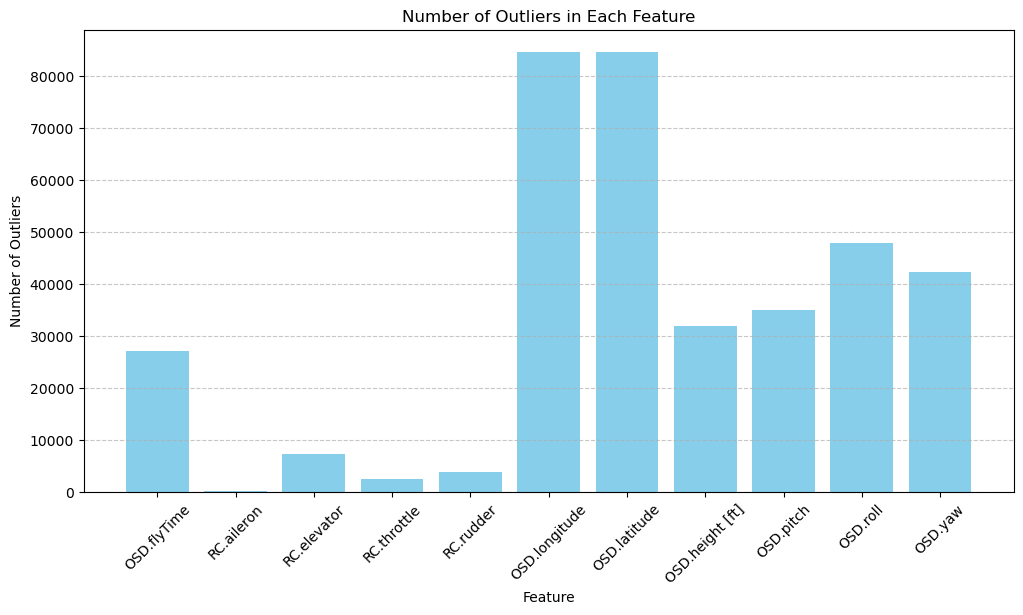

In [19]:
# Extract features and corresponding number of outliers
features = list(num_outliers_per_feature.keys())
num_outliers = list(num_outliers_per_feature.values())

# Plot the number of outliers for each feature
plt.figure(figsize=(12, 6))
plt.bar(features, num_outliers, color='skyblue')
plt.title('Number of Outliers in Each Feature')
plt.xlabel('Feature')
plt.ylabel('Number of Outliers')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Handle the Outliers

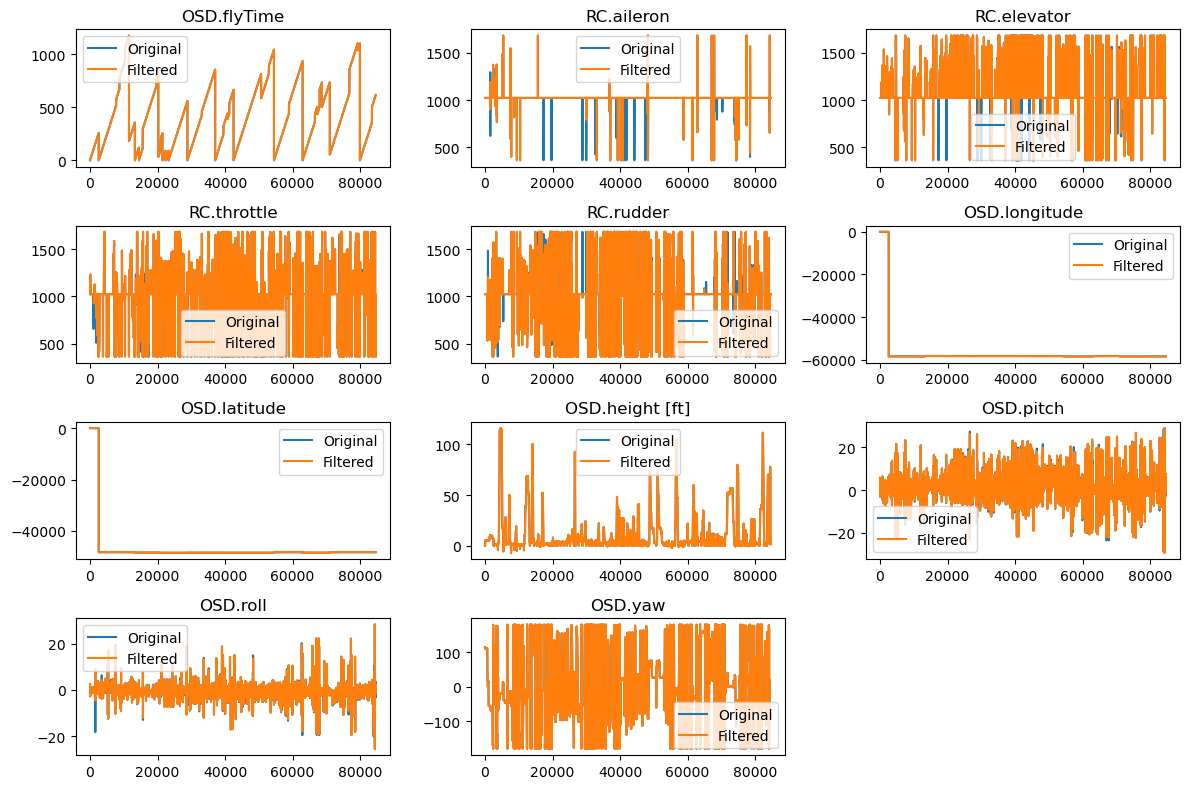

In [20]:
def two_sided_median_filter(data, window_size):
    """
    Perform two-sided median filtering for outlier detection.

    Parameters:
    - data: 1D numpy array containing the flight data
    - window_size: Size of the window for median filtering

    Returns:
    - filtered_data: Numpy array with outliers replaced by the median value of neighboring elements
    """
    filtered_data = np.zeros_like(data)
    half_window = window_size // 2

    for i in range(len(data)):
        lower_bound = max(0, i - half_window)
        upper_bound = min(len(data), i + half_window + 1)

        window = data[lower_bound:upper_bound]
        if len(window) > 0:  # Check if window is not empty
            median = np.median(window)

            if data[i] < median - 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            elif data[i] > median + 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            else:
                filtered_data[i] = data[i]
        else:
            # If window is empty, set the filtered value to the original value
            filtered_data[i] = data[i]

    return filtered_data


# Apply two-sided median filtering to each feature
window_size = 5  # You can adjust the window size as needed
for feature in features:
    df[feature + '_filtered'] = two_sided_median_filter(df[feature].values, window_size)

# Plot original and filtered dataa for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    plt.plot(df[feature], label='Original')
    plt.plot(df[feature + '_filtered'], label='Filtered')
    plt.title(feature)
    plt.legend()
plt.tight_layout()
plt.show()

In [21]:
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,...,RC.aileron_filtered,RC.elevator_filtered,RC.throttle_filtered,RC.rudder_filtered,OSD.longitude_filtered,OSD.latitude_filtered,OSD.height [ft]_filtered,OSD.pitch_filtered,OSD.roll_filtered,OSD.yaw_filtered
0,0.0,1024,1024,1024,1024,0.000000,0.000000,0.0,5.7,2.5,...,1024,1024,1024,1024,0.000000,0.000000,0.0,5.7,2.5,114.0
1,0.1,1024,1024,1024,1024,-0.003562,0.003311,0.0,5.7,2.5,...,1024,1024,1024,1024,-0.003562,0.003311,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,-0.013915,0.014348,0.0,5.7,2.5,...,1024,1024,1024,1024,-0.013915,0.014348,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,-0.018034,0.017659,0.0,5.7,2.5,...,1024,1024,1024,1024,-0.018034,0.012140,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,-0.027273,0.008829,0.0,5.7,2.5,...,1024,1024,1024,1024,-0.027273,0.014348,0.0,5.7,2.5,114.1


In [22]:
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Count outliers
outliers_count = np.sum(residuals > threshold)

print("Number of outliers detected:", outliers_count)


Number of outliers detected: 7383


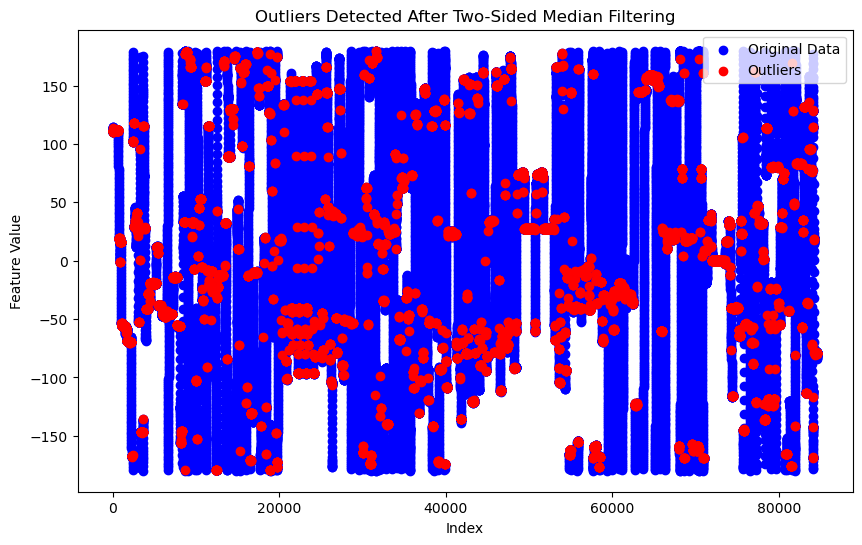

In [23]:
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Identify outliers
outliers = df[residuals > threshold]

# Visualize outliers
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df[feature], c='blue', label='Original Data')
plt.scatter(outliers.index, outliers[feature], c='red', label='Outliers')
plt.title('Outliers Detected After Two-Sided Median Filtering')
plt.xlabel('Index')
plt.ylabel('Feature Value')
plt.legend()
plt.show()


In [24]:
# Filter outliers
filtered_df = df[residuals <= threshold]

# Display the shape of the filtered DataFrame before and after removing outliers
print("Shape of original DataFrame:", df.shape)
print("Shape of filtered DataFrame (after removing outliers):", filtered_df.shape)


Shape of original DataFrame: (84593, 22)
Shape of filtered DataFrame (after removing outliers): (77210, 22)


In [25]:
df=filtered_df
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,0.1,1024,1024,1024,1024,-0.003562,0.003311,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,-0.013915,0.014348,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,-0.018034,0.017659,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,-0.027273,0.008829,0.0,5.7,2.5,114.1
5,0.5,1024,1024,1024,1024,-0.031949,0.012140,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
84588,614.7,1024,1024,364,1024,-58501.963978,-48257.848336,1.6,6.0,-0.4,-81.7
84589,614.8,1024,1024,364,1024,-58501.967874,-48257.853854,1.6,6.4,-0.4,-82.6
84590,614.9,1024,1024,364,1024,-58501.968319,-48257.865995,1.6,6.8,-0.4,-83.1
84591,615.0,1024,1024,364,1024,-58501.968764,-48257.892483,1.6,7.3,-1.0,-83.6


In [26]:
# Define a function to calculate outliers based on a criterion
def calculate_outliers(data, criterion):
    """
    Calculate outliers based on a criterion.

    Parameters:
    - data: 1D numpy array containing the feature data
    - criterion: Criterion for defining outliers (e.g., threshold value)

    Returns:
    - num_outliers: Number of outliers in the feature data
    """
    # Calculate median or mean of the data
    data_median = np.median(data)
    # Identify outliers based on the criterion
    outliers = data[data > criterion * data_median]
    # Count the number of outliers
    num_outliers = len(outliers)
    return num_outliers

# Define a threshold for identifying outliers (e.g., 1.5 times the median)
threshold = 1.5

# Calculate the number of outliers for each feature
num_outliers_per_feature = {}
for feature in features:
    num_outliers_per_feature[feature] = calculate_outliers(df[feature].values, threshold)

# Print the number of outliers for each feature
for feature, num_outliers in num_outliers_per_feature.items():
    print(f"Number of outliers in {feature}: {num_outliers}")


Number of outliers in OSD.flyTime: 24671
Number of outliers in RC.aileron: 88
Number of outliers in RC.elevator: 6743
Number of outliers in RC.throttle: 2165
Number of outliers in RC.rudder: 3803
Number of outliers in OSD.longitude: 77210
Number of outliers in OSD.latitude: 77210
Number of outliers in OSD.height [ft]: 28871
Number of outliers in OSD.pitch: 31788
Number of outliers in OSD.roll: 43588
Number of outliers in OSD.yaw: 38498


# Normalize other features

In [27]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron','RC.elevator','RC.throttle','RC.rudder','OSD.longitude','OSD.latitude','OSD.height [ft]','OSD.pitch','OSD.roll','OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.432326,0.02437,-0.514215,0.128465,-0.005746,5.932899,5.930712,-0.593514,1.143479,1.40955,1.185649
2,-1.431981,0.02437,-0.514215,0.128465,-0.005746,5.932898,5.930713,-0.593514,1.143479,1.40955,1.185649
3,-1.431636,0.02437,-0.514215,0.128465,-0.005746,5.932898,5.930713,-0.593514,1.143479,1.40955,1.185649
4,-1.431291,0.02437,-0.514215,0.128465,-0.005746,5.932897,5.930712,-0.593514,1.143479,1.40955,1.186746
5,-1.430946,0.02437,-0.514215,0.128465,-0.005746,5.932896,5.930713,-0.593514,1.143479,1.40955,1.186746


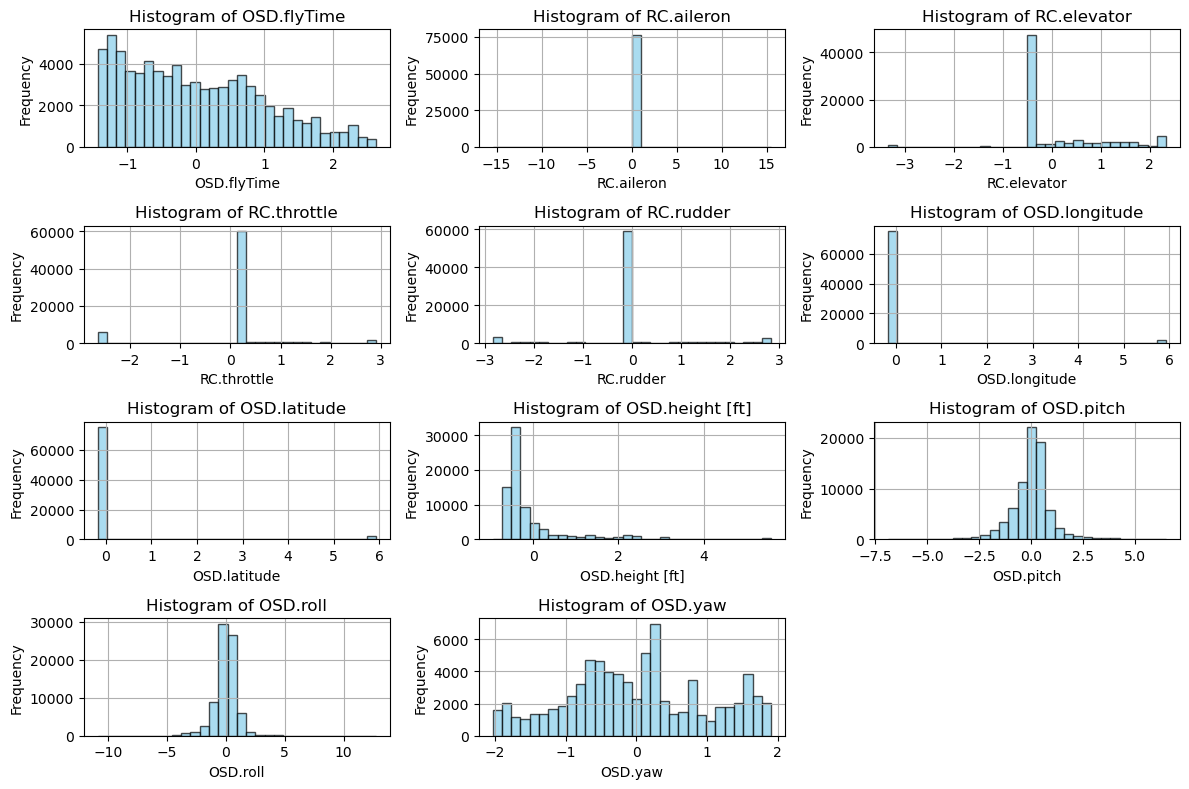

In [28]:
import matplotlib.pyplot as plt

# Plot histograms for all features in df
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df.columns):
    plt.subplot(4, 3, i+1)  # Adjust the subplot layout as needed
    plt.hist(df[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()  # Adjust the layout to prevent overlapping subplots
plt.show()


Range of values for each feature:
                       min        max
OSD.flyTime      -1.447997   2.754492
RC.aileron      -17.003712  17.030538
RC.elevator      -3.418412   2.315009
RC.throttle      -2.708535   2.972230
RC.rudder        -2.771154   2.731192
OSD.longitude    -0.200282   5.425563
OSD.latitude     -0.195355   5.426068
OSD.height [ft]  -0.949559   6.204311
OSD.pitch        -5.943698   6.510868
OSD.roll         -8.426128  10.316789
OSD.yaw          -2.005842   1.845610


<Figure size 1200x600 with 0 Axes>

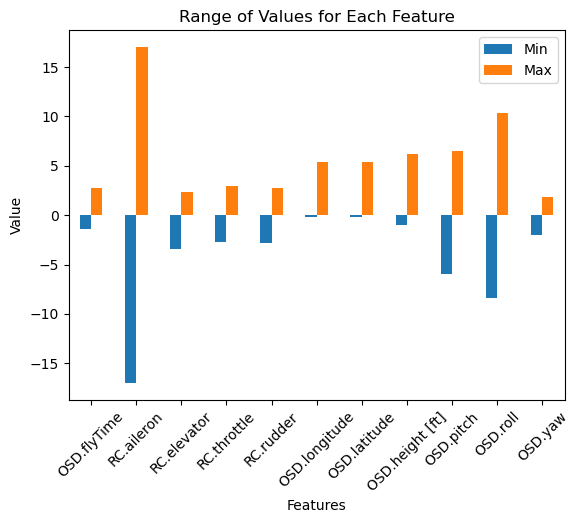

In [32]:
feature_ranges = df.describe().loc[['min', 'max']]

# Transpose the DataFrame for easier plotting
feature_ranges = feature_ranges.transpose()

print("Range of values for each feature:")
print(feature_ranges)
# Plot the range of values for each feature
plt.figure(figsize=(12, 6))
feature_ranges.plot(kind='bar', rot=45)
plt.title('Range of Values for Each Feature')
plt.xlabel('Features')
plt.ylabel('Value')
plt.legend(['Min', 'Max'])
plt.show()

# Distribution of each features

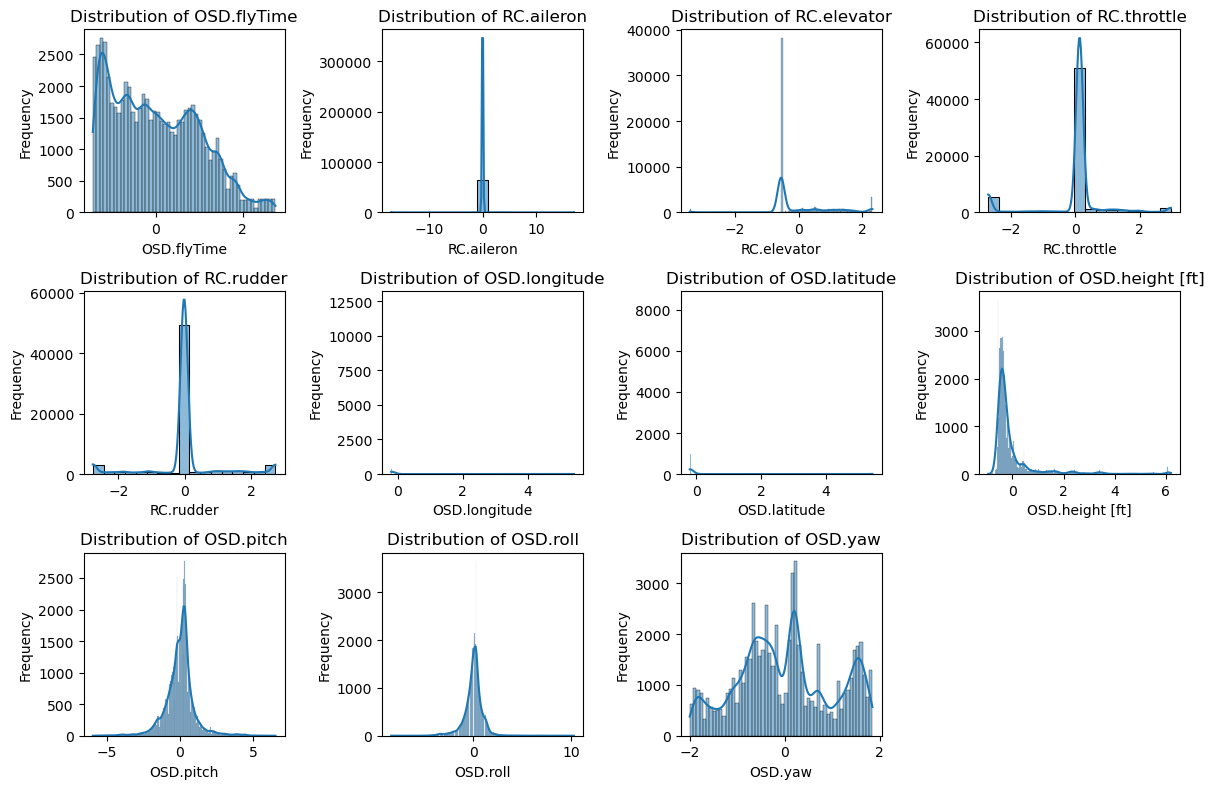

In [33]:
# Plot histograms for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Print correlation matrix
print("Correlation Matrix:")
correlation_matrix

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#### OSD.flyTime has a weak negative correlation with most variables.RC.aileron has a weak positive correlation with OSD.roll and a weak negative correlation with OSD.pitch.RC.elevator has a moderate positive correlation with OSD.height [ft] and a weak negative correlation with OSD.pitch.RC.throttle has no strong correlation with other variables.RC.rudder has a weak negative correlation with RC.aileron.OSD.longitude and OSD.latitude have a very strong positive correlation, which is expected since they represent coordinates on the same map.OSD.height [ft] has a weak negative correlation with RC.elevator.OSD.pitch has a moderate negative correlation with RC.elevator and a weak negative correlation with OSD.roll.OSD.roll has a weak positive correlation with RC.aileron and OSD.pitch.OSD.yaw has no strong correlation with other variables.

# BUild the model

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.base import BaseEstimator, RegressorMixin

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]


# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define a wrapper class for KerasRegressor
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001, epochs=100, batch_size=32):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def create_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.neurons, activation='relu', input_shape=(X_train.shape[1],)))
        model.add(layers.Dropout(self.dropout_rate))
        for _ in range(self.layers - 1):
            model.add(layers.Dense(self.neurons, activation='relu'))
            model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(len(output_targets)))
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')
        return model

    def fit(self, X, y):
        self.model = self.create_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Define hyperparameters to tune
param_dist = {
    'layers': [1, 2, 3], # number of hidden layers
    'neurons': [32, 64, 128], # number of neurons per layer
    'dropout_rate': [0.3, 0.5], # dropout rate
    'learning_rate': [0.001, 0.0001], # learning rate
    'epochs': [50, 100], # number of training epochs
    'batch_size': [32, 64] # batch size
}

# Create KerasRegressor wrapper
model = KerasRegressorWrapper()

# Perform random search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=2, random_state=42, n_jobs=1)

random_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Extract results from random search
results = pd.DataFrame(random_search.cv_results_)

# Define hyperparameters to plot
hyperparameters = ['param_layers', 'param_neurons', 'param_dropout_rate', 'param_learning_rate',
                   'param_epochs', 'param_batch_size']

# Plot random search results
plt.figure(figsize=(12, 12))
for i, param in enumerate(hyperparameters):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=param, y='mean_test_score', data=results, ax=plt.gca())
    plt.title(f'Random Search CV - {param}')
    plt.xlabel(param)
    plt.ylabel('Mean Test Score')
plt.tight_layout()
plt.show()


In [400]:
# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the model using best parameters
model = keras.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.3))
for _ in range(2):
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
model.add(layers.Dense(len(output_targets)))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test Mean Squared Error:", mse)

Epoch 1/100
650/650 [==============================] - 4s 4ms/step - loss: 0.9204 - val_loss: 0.8777
Epoch 2/100
650/650 [==============================] - 3s 4ms/step - loss: 0.8791 - val_loss: 0.8609
Epoch 3/100
650/650 [==============================] - 3s 4ms/step - loss: 0.8585 - val_loss: 0.8418
Epoch 4/100
650/650 [==============================] - 3s 4ms/step - loss: 0.8354 - val_loss: 0.8230
Epoch 5/100
650/650 [==============================] - 2s 4ms/step - loss: 0.8241 - val_loss: 0.8107
Epoch 6/100
650/650 [==============================] - 2s 4ms/step - loss: 0.8142 - val_loss: 0.8073
Epoch 7/100
650/650 [==============================] - 2s 4ms/step - loss: 0.8040 - val_loss: 0.7915
Epoch 8/100
650/650 [==============================] - 2s 4ms/step - loss: 0.7991 - val_loss: 0.7864
Epoch 9/100
650/650 [==============================] - 2s 4ms/step - loss: 0.7955 - val_loss: 0.7843
Epoch 10/100
650/650 [==============================] - 2s 4ms/step - loss: 0.7909 - val_lo

OSD.longitude - Mean Squared Error: 77.48, R-squared: -22.20%, Mean Absolute Error: 3.95, Variance Explained: -22.20%
OSD.latitude - Mean Squared Error: 34.84, R-squared: -6.11%, Mean Absolute Error: 3.02, Variance Explained: -6.11%
OSD.height [ft] - Mean Squared Error: 67.75, R-squared: -462.68%, Mean Absolute Error: 7.48, Variance Explained: -462.68%
OSD.pitch - Mean Squared Error: 11.03, R-squared: -4.14%, Mean Absolute Error: 2.30, Variance Explained: -4.14%
OSD.roll - Mean Squared Error: 15.48, R-squared: -43.72%, Mean Absolute Error: 2.55, Variance Explained: -43.72%
OSD.yaw - Mean Squared Error: 2871.30, R-squared: -10.51%, Mean Absolute Error: 36.27, Variance Explained: -10.51%


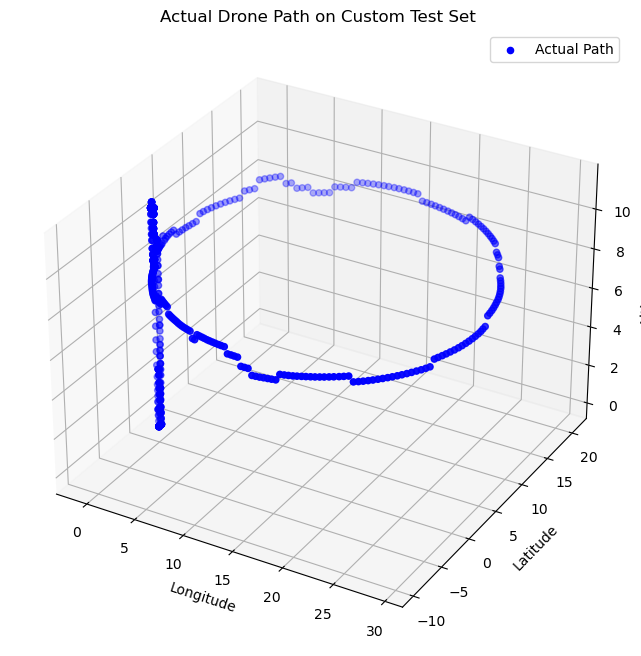

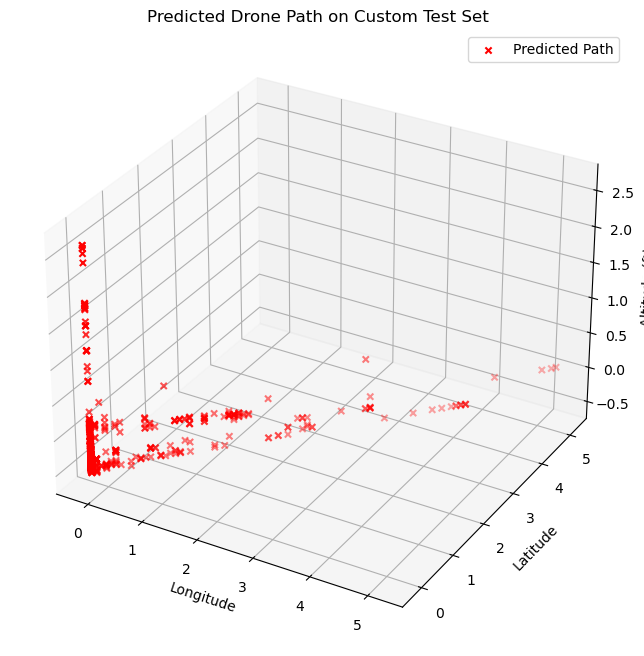

In [435]:
import os
import math
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon

    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Read the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)


features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']
df_test_custom=df_test_custom[features]

# Normalization using StandardScaler
scaler = StandardScaler()
df_test_custom_scaled = scaler.fit_transform(df_test_custom)

X_test_custom_scaled = df_test_custom_scaled[:, :5]  # Select the first 5 columns after scaling


# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i])
    r2_custom = r2_score(df_test_custom[target_variable], y_pred_custom[:, i])
    mae_custom = mean_absolute_error(df_test_custom[target_variable], y_pred_custom[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')


# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()



Feature Importance:
       Feature  Importance
0  OSD.flyTime    0.579999
2  RC.elevator    0.192756
4    RC.rudder    0.109889
3  RC.throttle    0.092993
1   RC.aileron    0.024364


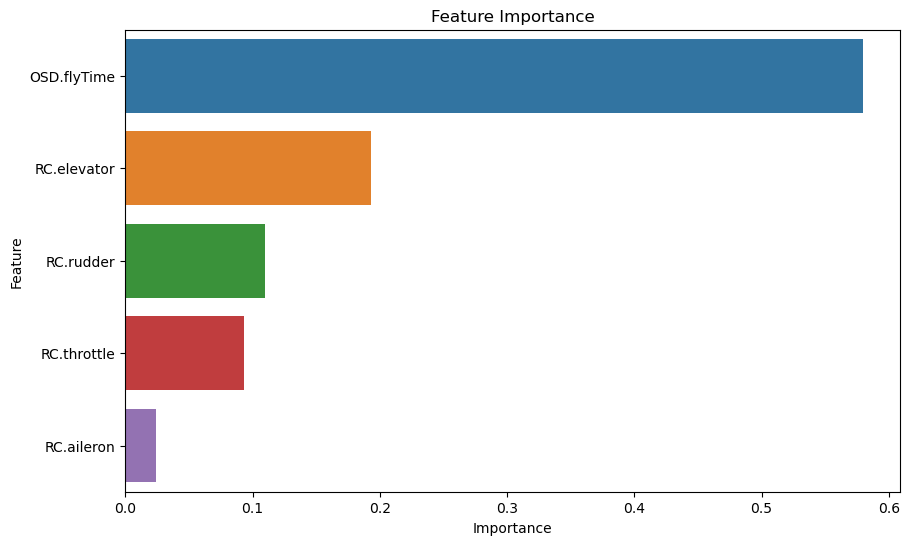

In [434]:
# Train a model with feature importances (example: RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor

# Define and fit the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': input_features, 'Importance': feature_importances})

# Sort the DataFrame by feature importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the sorted DataFrame
print("Feature Importance:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
